In [1]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Iterable, Tuple

from seaborn import color_palette

import plot_benchmark
from pathlib import Path
import os

%load_ext autoreload
%autoreload
%matplotlib inline

time_results = Path("../results/2025-10-25_18-51_Benchmark_Result_RTX2080_without_shr.csv")
code_complexity_results = Path("../results/code-complexity_without_shr.csv")

In [2]:
df_results = pd.read_csv(time_results)
df_results

,Name,Framework,Precision,Problem Size,Iterations,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,Time Unit,Version,Framework[Version]
0,MatrixMultiplication,Alpaka,float,32,8176.0,7.831260e+04,7.812443e+04,2.394853e+04,NaN,NaN,NaN,ns,NaN,Alpaka
1,MatrixMultiplication,Alpaka,float,64,6900.0,1.129272e+05,1.126394e+05,3.995484e+04,NaN,NaN,NaN,ns,NaN,Alpaka
2,MatrixMultiplication,Alpaka,float,128,4426.0,1.576464e+05,1.573337e+05,7.470166e+04,NaN,NaN,NaN,ns,NaN,Alpaka
3,MatrixMultiplication,Alpaka,float,256,1168.0,6.227995e+05,6.217590e+05,4.624265e+05,NaN,NaN,NaN,ns,NaN,Alpaka
4,MatrixMultiplication,Alpaka,float,512,176.0,3.889060e+06,3.883924e+06,3.329796e+06,NaN,NaN,NaN,ns,NaN,Alpaka
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,PolyhedralGravity,CPP,float,255932,20.0,3.408281e+07,3.407821e+07,NaN,NaN,NaN,NaN,ns,NaN,CPP
229,PolyhedralGravity,Cuda,float,14744,2469.0,2.665432e+05,2.667564e+05,NaN,NaN,NaN,NaN,ns,NaN,Cuda
230,PolyhedralGravity,Cuda,float,255932,241.0,2.887818e+06,2.889847e+06,NaN,NaN,NaN,NaN,ns,NaN,Cuda
231,PolyhedralGravity,OpenMP,float,14744,9149.0,4.153860e+05,6.815568e+04,NaN,NaN,NaN,NaN,ns,NaN,OpenMP


Compute and append Halstead metrics (n, N, V, D, E) to df_complexity and df_merged using:
- n = n1 + n2
- N = N1 + N2
- V = N * log2(n)
- D = (n1 / 2) * (N2 / n2)
- E = D * V

In [3]:
df_complexity = pd.read_csv(code_complexity_results)
df_complexity["n"] = df_complexity["n1"] + df_complexity["n2"]
df_complexity["N"] = df_complexity["N1"] + df_complexity["N2"]
df_complexity["V"] = df_complexity["N"] * np.log2(df_complexity["n"].replace(0, np.nan))
df_complexity["D"] = (df_complexity["n1"] / 2) * (df_complexity["N2"] / df_complexity["n2"].replace(0, np.nan))
df_complexity["E"] = df_complexity["D"] * df_complexity["V"]
df_complexity

,Name,Framework,SLOC,n1,n2,N1,N2,n,N,V,D,E
0,VecAdd,CPP,30,37,42,183,89,79,272,1714.628364,39.202381,6.721751e+04
1,VecAdd,Alpaka,83,44,96,487,295,140,782,5575.099319,67.604167,3.768999e+05
2,VecAdd,Boost,49,51,57,322,187,108,509,3438.237739,83.657895,2.876357e+05
3,VecAdd,AdaptiveCpp,47,52,64,338,154,116,492,3374.126650,62.562500,2.110938e+05
4,VecAdd,Cuda,76,61,48,399,172,109,571,3864.633249,109.291667,4.223722e+05
5,VecAdd,Cublas,66,48,47,368,159,95,527,3462.313906,81.191489,2.811104e+05
6,VecAdd,OpenACC,41,52,52,246,123,104,369,2472.462256,61.500000,1.520564e+05
7,VecAdd,OpenCL,143,82,96,894,369,178,1263,9441.851323,157.593750,1.487977e+06
8,VecAdd,OpenMP,37,45,53,219,121,98,340,2249.001347,51.367925,1.155265e+05
9,VecAdd,Vulkan,206,92,198,1394,769,290,2163,17693.143362,178.656566,3.160996e+06


In [4]:
# Merge df_results and df_complexity on ['Name', 'Framework']
df_merged = pd.merge(df_results, df_complexity, on=["Name", "Framework"], how="inner")
df_merged = df_merged.drop(columns=["Version", "Framework[Version]", "Precision", "Iterations", "Time Unit"])
df_merged


,Name,Framework,Problem Size,Wall Clock Time,CPU Time,Kernel Time,Position Update Time,Velocity Update Time,Force Update Time,SLOC,n1,n2,N1,N2,n,N,V,D,E
0,MatrixMultiplication,Alpaka,32,7.831260e+04,7.812443e+04,2.394853e+04,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
1,MatrixMultiplication,Alpaka,64,1.129272e+05,1.126394e+05,3.995484e+04,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
2,MatrixMultiplication,Alpaka,128,1.576464e+05,1.573337e+05,7.470166e+04,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
3,MatrixMultiplication,Alpaka,256,6.227995e+05,6.217590e+05,4.624265e+05,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
4,MatrixMultiplication,Alpaka,512,3.889060e+06,3.883924e+06,3.329796e+06,NaN,NaN,NaN,109,48,116,635,405,164,1040,7651.854085,83.793103,6.411726e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,PolyhedralGravity,CPP,255932,3.408281e+07,3.407821e+07,NaN,NaN,NaN,NaN,541,79,239,3262,1955,318,5217,43368.310378,323.106695,1.401259e+07
231,PolyhedralGravity,Cuda,14744,2.665432e+05,2.667564e+05,NaN,NaN,NaN,NaN,718,100,299,4218,2620,399,6838,59081.994874,438.127090,2.588542e+07
232,PolyhedralGravity,Cuda,255932,2.887818e+06,2.889847e+06,NaN,NaN,NaN,NaN,718,100,299,4218,2620,399,6838,59081.994874,438.127090,2.588542e+07
233,PolyhedralGravity,OpenMP,14744,4.153860e+05,6.815568e+04,NaN,NaN,NaN,NaN,574,92,252,3442,2025,344,5467,46066.389414,369.642857,1.702811e+07


In [5]:
def filter_and_normalize(df: pd.DataFrame,
                         name: str,
                         problem_size: int,
                         runtime: str = "Kernel Time",
                         exclude: str | list[str] = "Cublas") -> pd.DataFrame:
    """
    Filter by Name and Problem Size, exclude frameworks, and compute:
    - Application Efficiency [%]: normalized inverse of chosen runtime column (lower is better -> higher score)
    - E_normalized [%]: Halstead Effort normalized to max=100

    Parameters
    ----------
    df : pd.DataFrame
        Merged dataframe that contains runtime columns and Halstead metrics.
    name : str
        Value to match in 'Name'.
    problem_size : int
        Value to match in 'Problem Size'.
    runtime : str, default "Kernel Time"
        Column to use for application efficiency (e.g., "Kernel Time", "CPU Time", "Wall Clock Time").
    exclude : str | list[str], default "Cublas"
        Framework name(s) to exclude entirely.

    Returns
    -------
    pd.DataFrame
        Filtered dataframe with added columns:
        - "Application Efficiency [%]"
        - "E_normalized [%]"
    """
    df = df.copy()
    required_cols = {"Framework", "Name", "Problem Size", runtime, "E"}
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Filter by name and problem size
    out = df.loc[(df["Name"] == name) & (df["Problem Size"] == problem_size)].copy()

    # Exclude frameworks
    if exclude:
        excl = [exclude] if isinstance(exclude, str) else list(exclude)
        out = out.loc[~out["Framework"].isin(excl)]

    # Drop columns not needed for the analysis if they exist
    to_drop = ["Name", "Problem Size"]
    existing_drop = [c for c in to_drop if c in out.columns]
    if existing_drop:
        out.drop(columns=existing_drop, inplace=True)

    # Application Efficiency: normalize inverse (best/fastest = 100)
    runtime_series = out[runtime].astype(float)
    min_val = runtime_series.min()
    out["Application Efficiency [%]"] = (min_val / runtime_series) * 100.0

    # Halstead Effort normalized to max=100
    e_series = out["E"].astype(float)
    max_e = e_series.max()
    out["Halstead Effort Normalized [%]"] = (e_series / max_e) * 100.0 if np.isfinite(max_e) and max_e != 0 else e_series

    return out


In [6]:
def filter_and_concat(
        df: pd.DataFrame,
        queries: Iterable[Tuple[str, int, str | None]],
        exclude: str | list[str] = "Cublas",
) -> pd.DataFrame:
    """
    Run filter_and_normalize multiple times and concatenate results.
    Each query is a tuple of (name, problem_size, runtime). If runtime is None, defaults to "Kernel Time".
    The resulting dataframe will include the original Name and Problem Size for each query.
    """
    frames: list[pd.DataFrame] = []
    for q in queries:
        if len(q) != 3:
            raise ValueError("Each query must be a tuple: (name, problem_size, runtime)")
        name, problem_size, runtime = q
        rt = runtime if runtime is not None else "Kernel Time"
        out = filter_and_normalize(df, name=name, problem_size=problem_size, runtime=rt, exclude=exclude).copy()
        # Re-add the identifying columns
        out["Name"] = name
        out["Problem Size"] = problem_size
        out["Runtime Column"] = rt
        frames.append(out)

    if not frames:
        return pd.DataFrame(columns=["Name", "Problem Size", "Runtime Column"])

    return pd.concat(frames, ignore_index=True)


In [7]:
df_merged["Framework"].unique()

array(['Alpaka', 'OpenMP', 'Vulkan', 'AdaptiveCpp', 'AdaptiveCpp-Shr',
       'CPP', 'OpenCL', 'Boost', 'Kokkos', 'Cublas', 'Cuda', 'Cuda-Shr',
       'OpenACC', 'Slang-Cuda', 'Slang-Vulkan'], dtype=object)

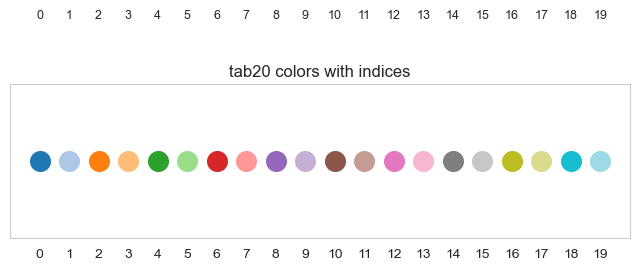

In [8]:
colors = matplotlib.colormaps["tab20"].colors
plt.figure(figsize=(8, 2))
for i, c in enumerate(colors):
    plt.scatter(i, 0, color=c, s=200)
    plt.text(i, 0.1, str(i), ha="center", va="bottom", fontsize=9)
plt.yticks([])
plt.xticks(range(len(colors)))
plt.xlim(-1, len(colors))
plt.title("tab20 colors with indices")
plt.grid(False)
plt.show()


In [9]:
frameworks = [
    "Alpaka", "OpenMP", "Vulkan", "AdaptiveCpp", "AdaptiveCpp-Shr",
    "CPP", "OpenCL", "Boost", "Kokkos", "Cublas", "Cuda", "Cuda-Shr",
    "OpenACC", "Slang-Cuda", "Slang-Vulkan"
]
tab20 = matplotlib.colormaps["tab20"].colors
color_map = {
    "CPP": tab20[0],
    
    "Vulkan": tab20[2],
    "Slang-Vulkan": tab20[3],

    "Cuda": tab20[8],
    "Slang-Cuda": tab20[9],
    "Cuda-Shr": tab20[12],
    "Cublas": tab20[13],
    
    "AdaptiveCpp": tab20[4],
    "AdaptiveCpp-Shr": tab20[5],
    
    "OpenACC": tab20[14],
    "OpenMP": tab20[18],

    "Alpaka": tab20[10],

    "OpenCL": tab20[16],
    "Boost": tab20[17],
    
    "Kokkos": tab20[6],
}

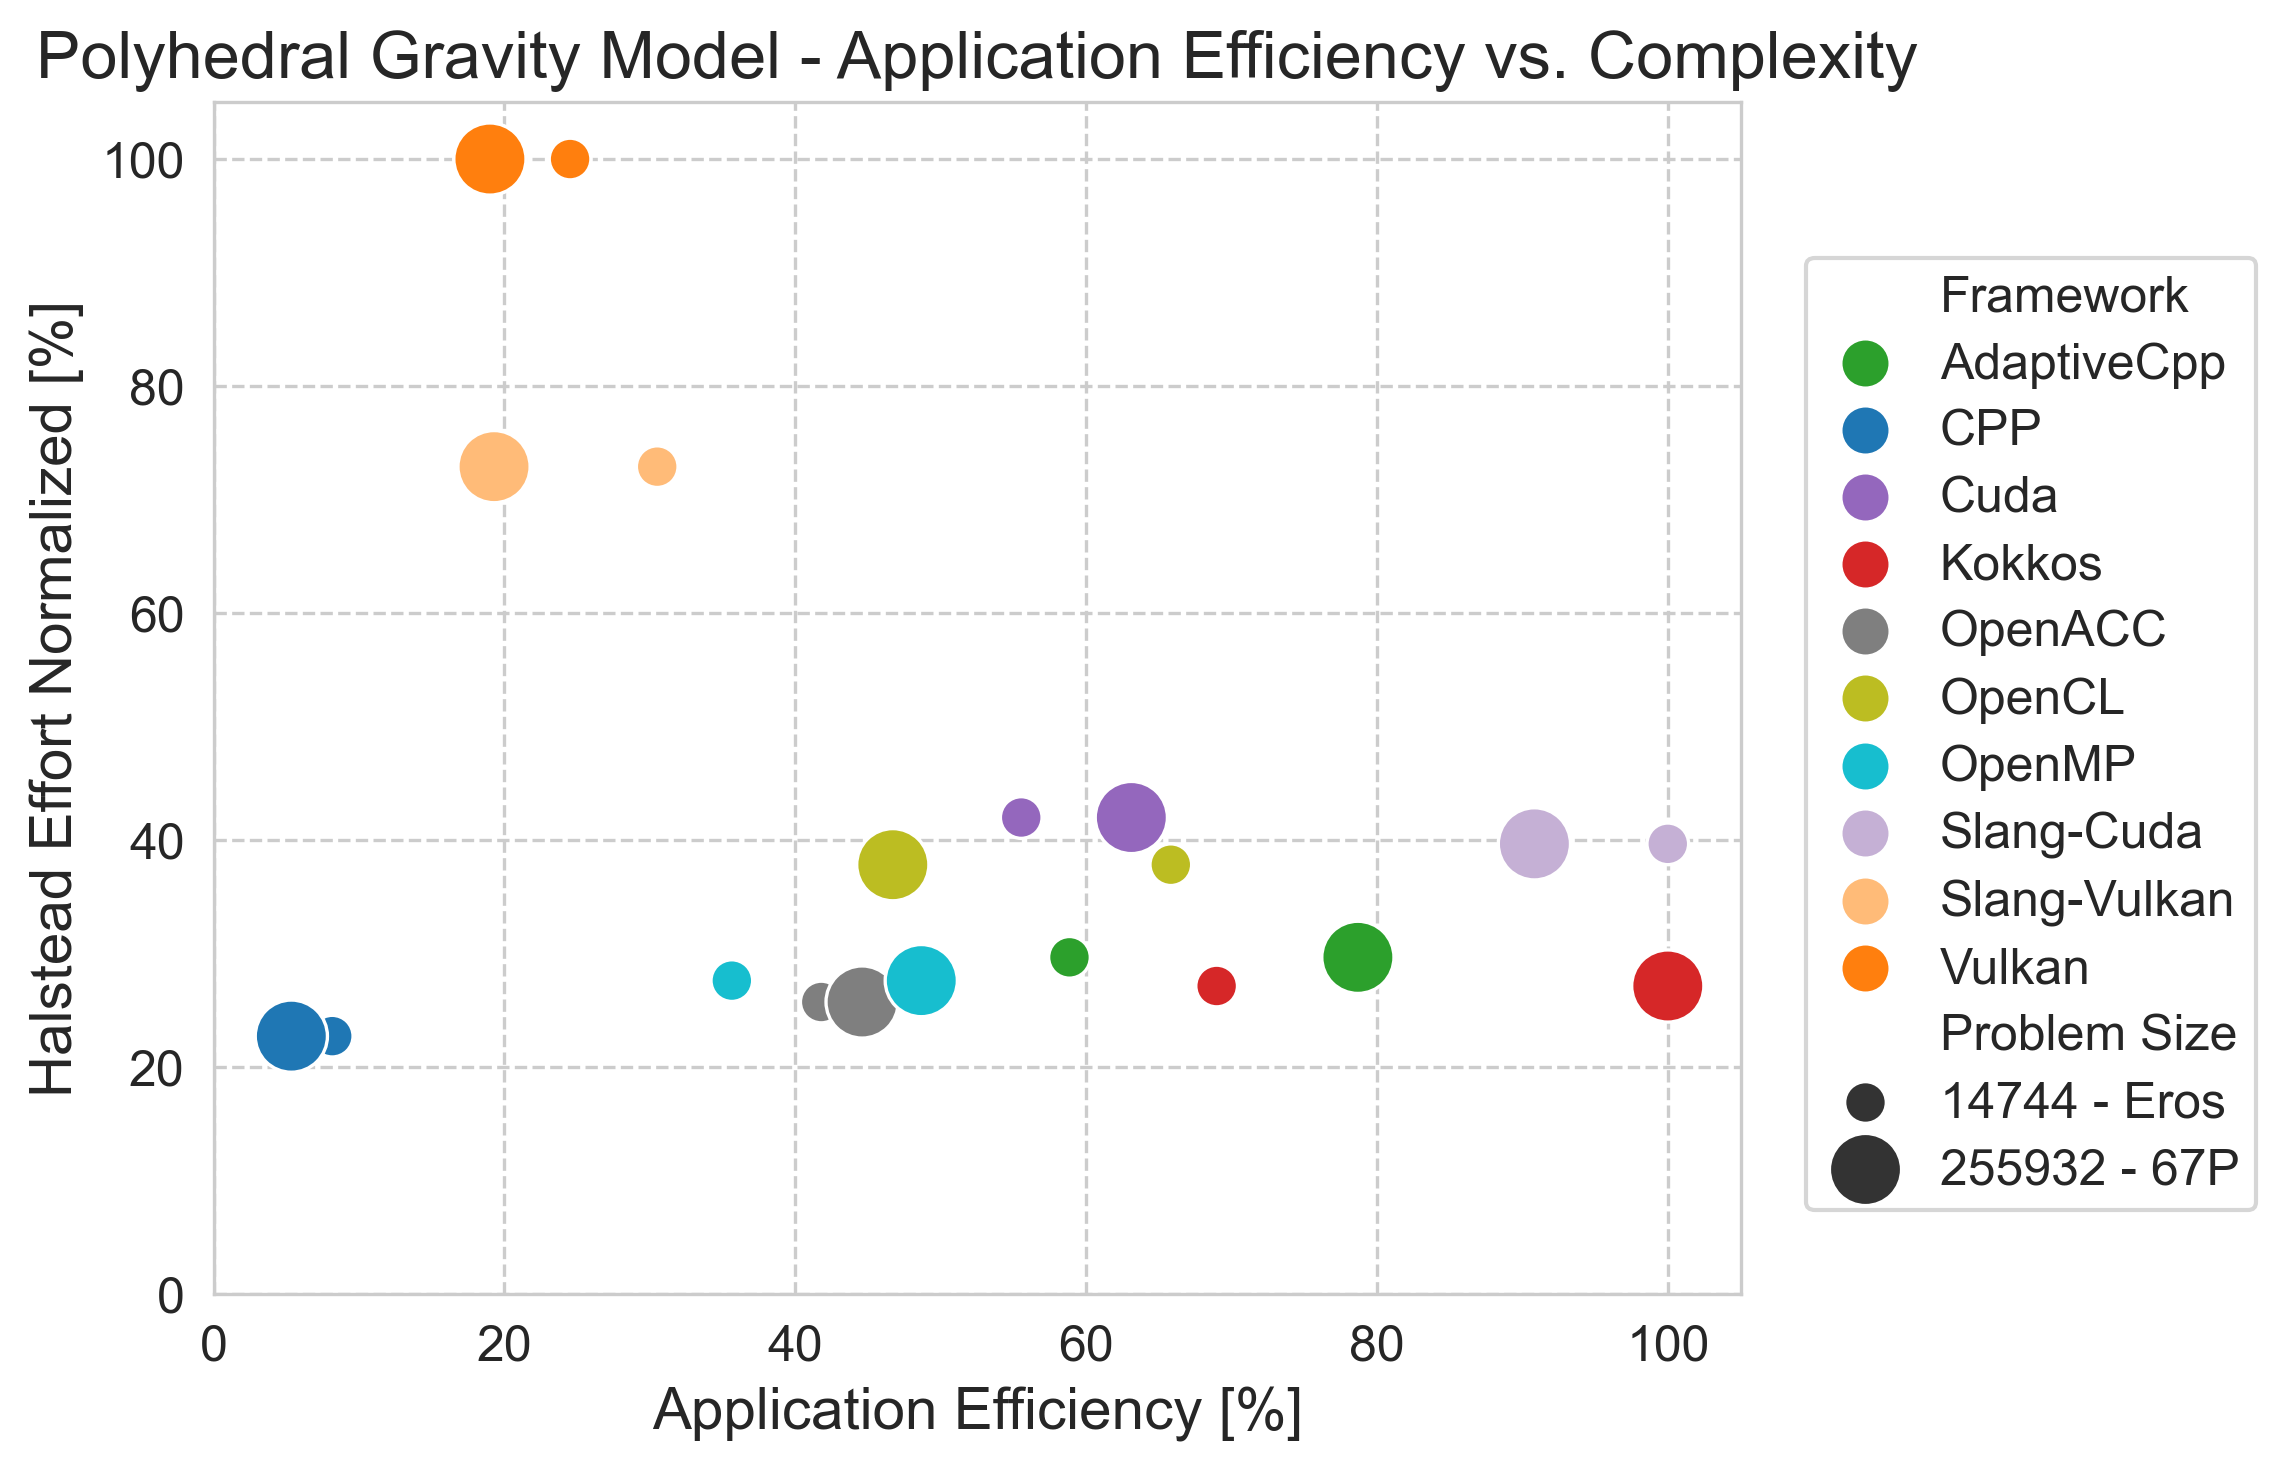

In [10]:
df_polyhedral = filter_and_concat(df_merged, [("PolyhedralGravity", 14744, "Wall Clock Time"),
                                              ("PolyhedralGravity", 255932, "Wall Clock Time")
                                              ])
plt.figure(figsize=(6, 5))
ax = sns.scatterplot(
    data=df_polyhedral,
    x="Application Efficiency [%]",
    y="Halstead Effort Normalized [%]",
    hue="Framework",
    size="Problem Size",
    sizes=(100, 300),
    palette=color_map,
    s=140
)
ax.grid(True, linestyle="--")
ax.set_ylim(0, 105)
ax.set_xlim(0, 105)
ax.set_title("Polyhedral Gravity Model - Application Efficiency vs. Complexity", fontsize=16)
ax.set_xlabel("Application Efficiency [%]", fontsize=14)
ax.set_ylabel("Halstead Effort Normalized [%]", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

# Move legend to the right outside the plot
legend = ax.legend_
if legend is not None:
    handles, labels = legend.legend_handles, [t.get_text() for t in legend.texts]
    legend.remove()
    # Rename last two size labels
    labels[-2] = "14744 - Eros"
    labels[-1] = "255932 - 67P"
    # Separate entries for Framework and Problem Size
    # Find the split position by detecting the "Problem Size" header (from seaborn legend)
    # labels structure: ["Framework", <frameworks...>, "Problem Size", <sizes...>]
    if "Problem Size" in labels:
        split_idx = labels.index("Problem Size")
        fw_title = labels[0]
        fw_labels = labels[1:split_idx]
        size_title = labels[split_idx]
        size_labels = labels[split_idx + 1:]
        fw_handles = handles[1:split_idx]
        size_handles = handles[split_idx + 1:]
        # Sort framework legend alphabetically
        fw_pairs = sorted(zip(fw_labels, fw_handles), key=lambda x: x[0].lower())
        fw_labels_sorted, fw_handles_sorted = zip(*fw_pairs) if fw_pairs else ([], [])
        # Reassemble legend parts
        labels = [fw_title, *fw_labels_sorted, size_title, *size_labels]
        handles = [handles[0], *fw_handles_sorted, handles[split_idx], *size_handles]
    leg = ax.figure.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=True
    )
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(13)
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()


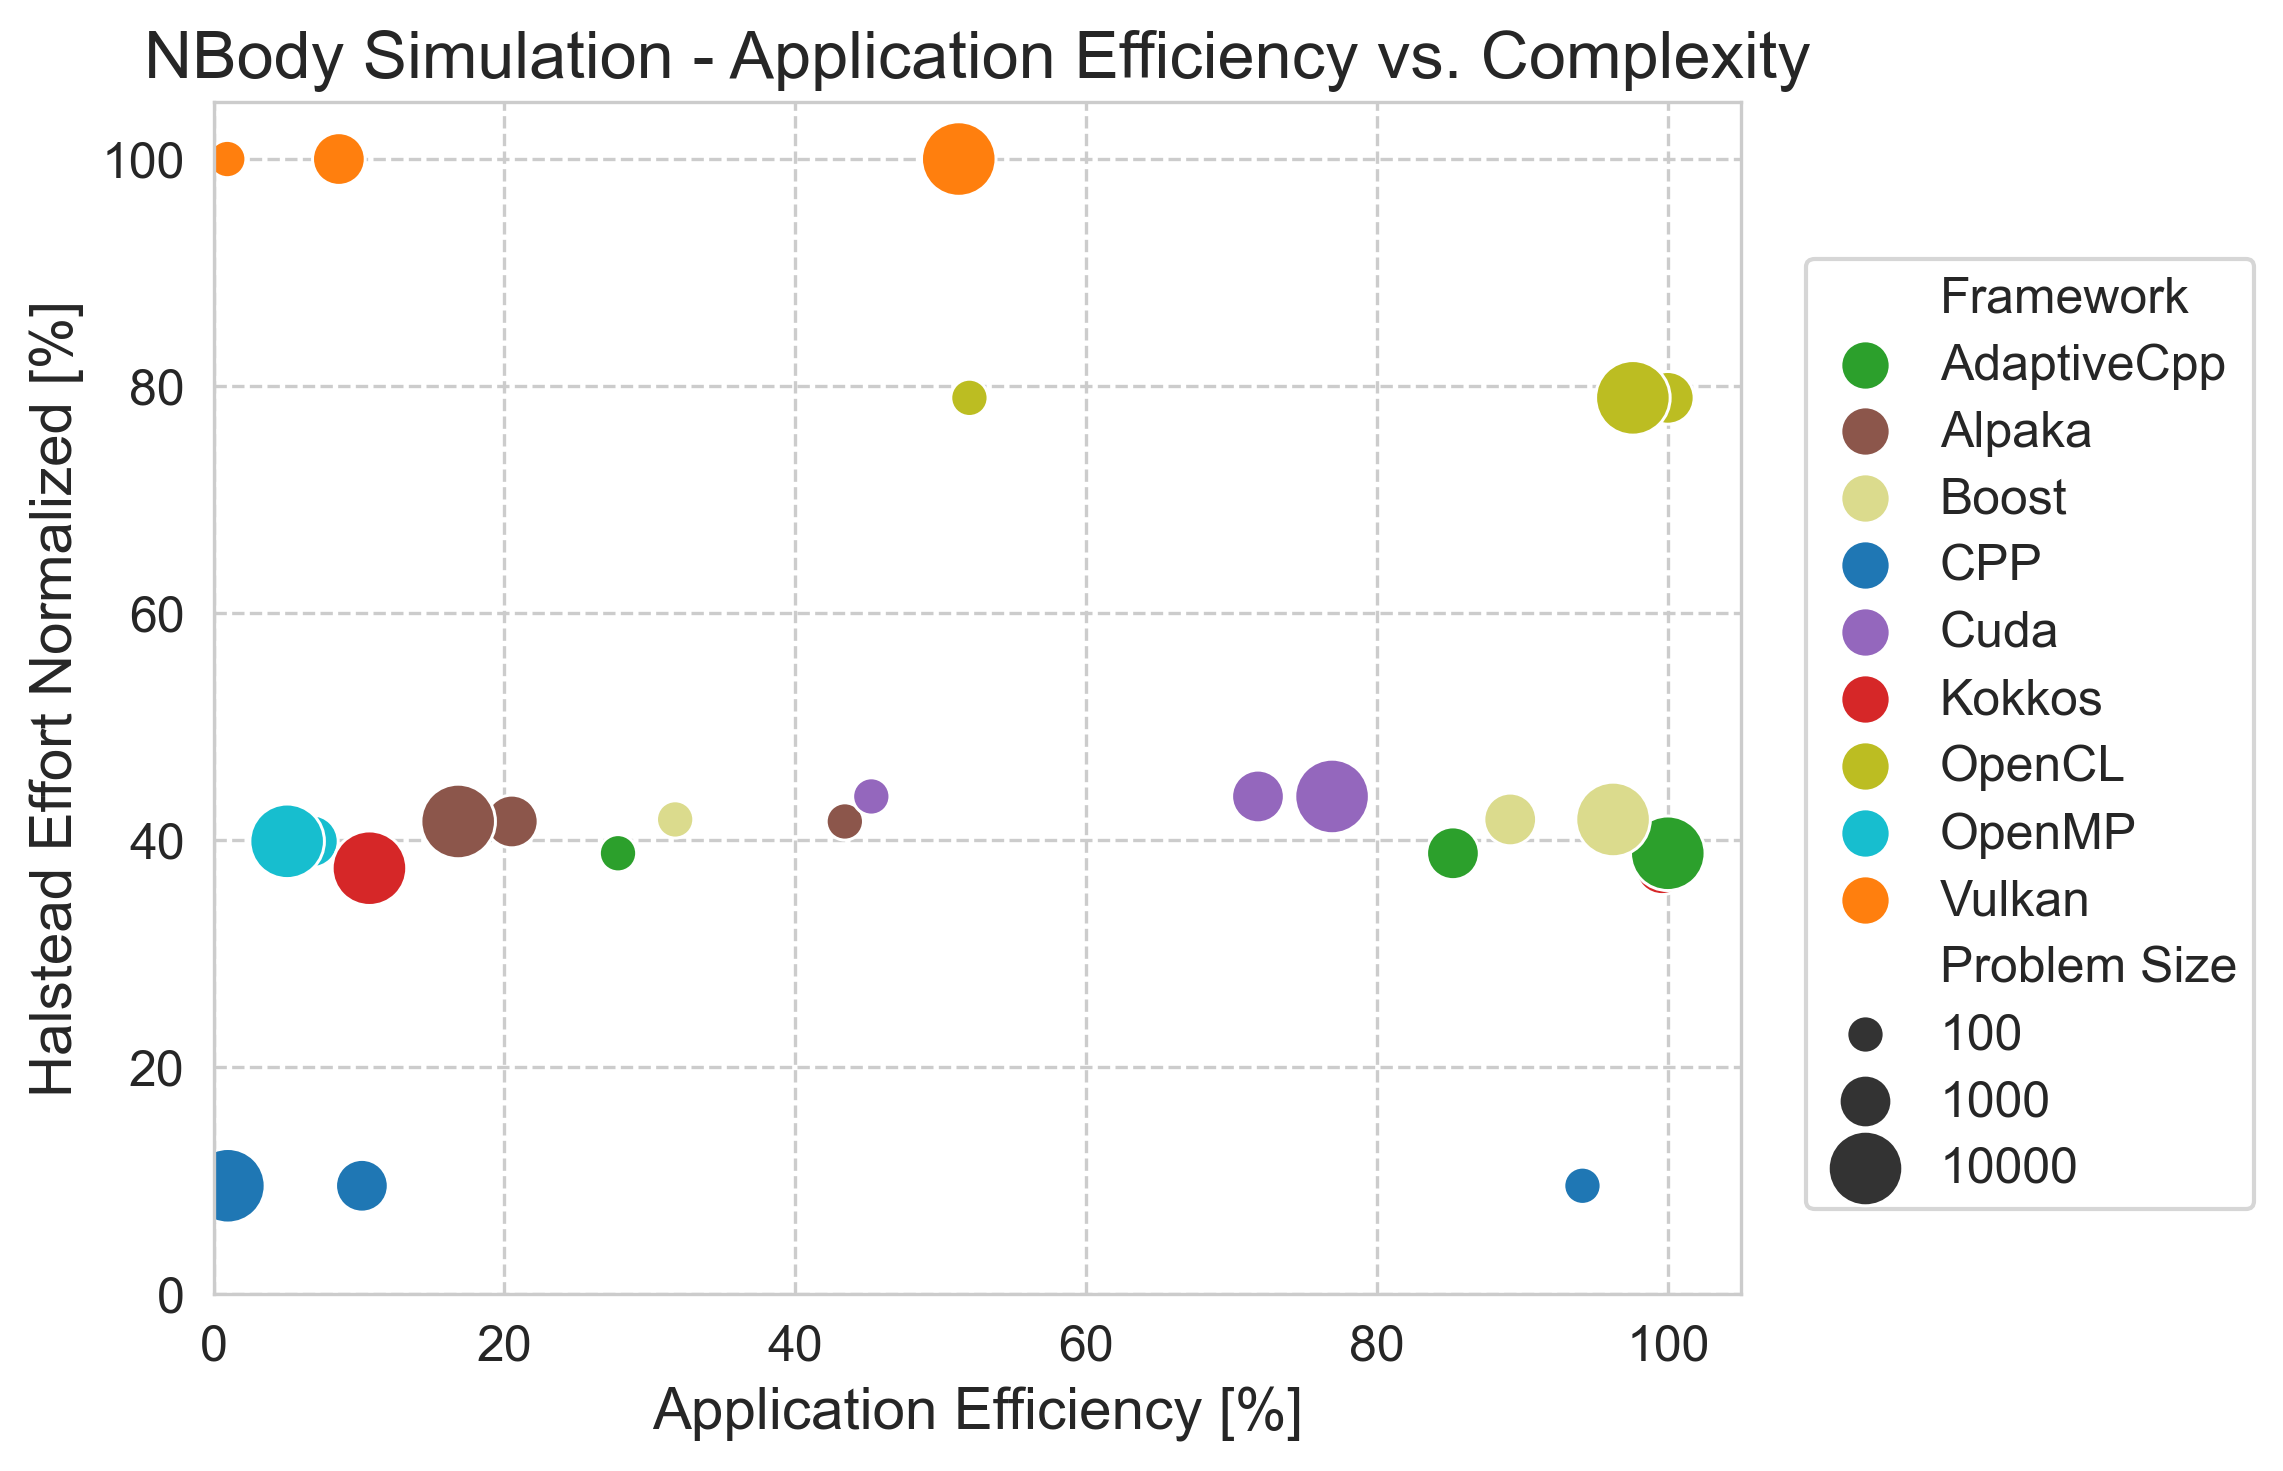

In [11]:
df_nbody= filter_and_concat(df_merged, [
                                              ("NBody", 100, "Wall Clock Time"),
                                              ("NBody", 1000, "Wall Clock Time"),
                                              ("NBody", 10000, "Wall Clock Time")
                                              ])
plt.figure(figsize=(6, 5))
ax = sns.scatterplot(
    data=df_nbody,
    x="Application Efficiency [%]",
    y="Halstead Effort Normalized [%]",
    hue="Framework",
    size="Problem Size",
    sizes=[80, 160, 320],
    palette=color_map,
    s=140
)
ax.grid(True, linestyle="--")
ax.set_ylim(0, 105)
ax.set_xlim(0, 105)
ax.set_title("NBody Simulation - Application Efficiency vs. Complexity", fontsize=16)
ax.set_xlabel("Application Efficiency [%]", fontsize=14)
ax.set_ylabel("Halstead Effort Normalized [%]", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

# Move legend to the right outside the plot
legend = ax.legend_
if legend is not None:
    handles, labels = legend.legend_handles, [t.get_text() for t in legend.texts]
    legend.remove()
    if "Problem Size" in labels:
        split_idx = labels.index("Problem Size")
        fw_title = labels[0]
        fw_labels = labels[1:split_idx]
        size_title = labels[split_idx]
        size_labels = labels[split_idx + 1:]
        fw_handles = handles[1:split_idx]
        size_handles = handles[split_idx + 1:]
        # Sort framework legend alphabetically
        fw_pairs = sorted(zip(fw_labels, fw_handles), key=lambda x: x[0].lower())
        fw_labels_sorted, fw_handles_sorted = zip(*fw_pairs) if fw_pairs else ([], [])
        # Reassemble legend parts
        labels = [fw_title, *fw_labels_sorted, size_title, *size_labels]
        handles = [handles[0], *fw_handles_sorted, handles[split_idx], *size_handles]
    leg = ax.figure.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=True
    )
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(13)
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()


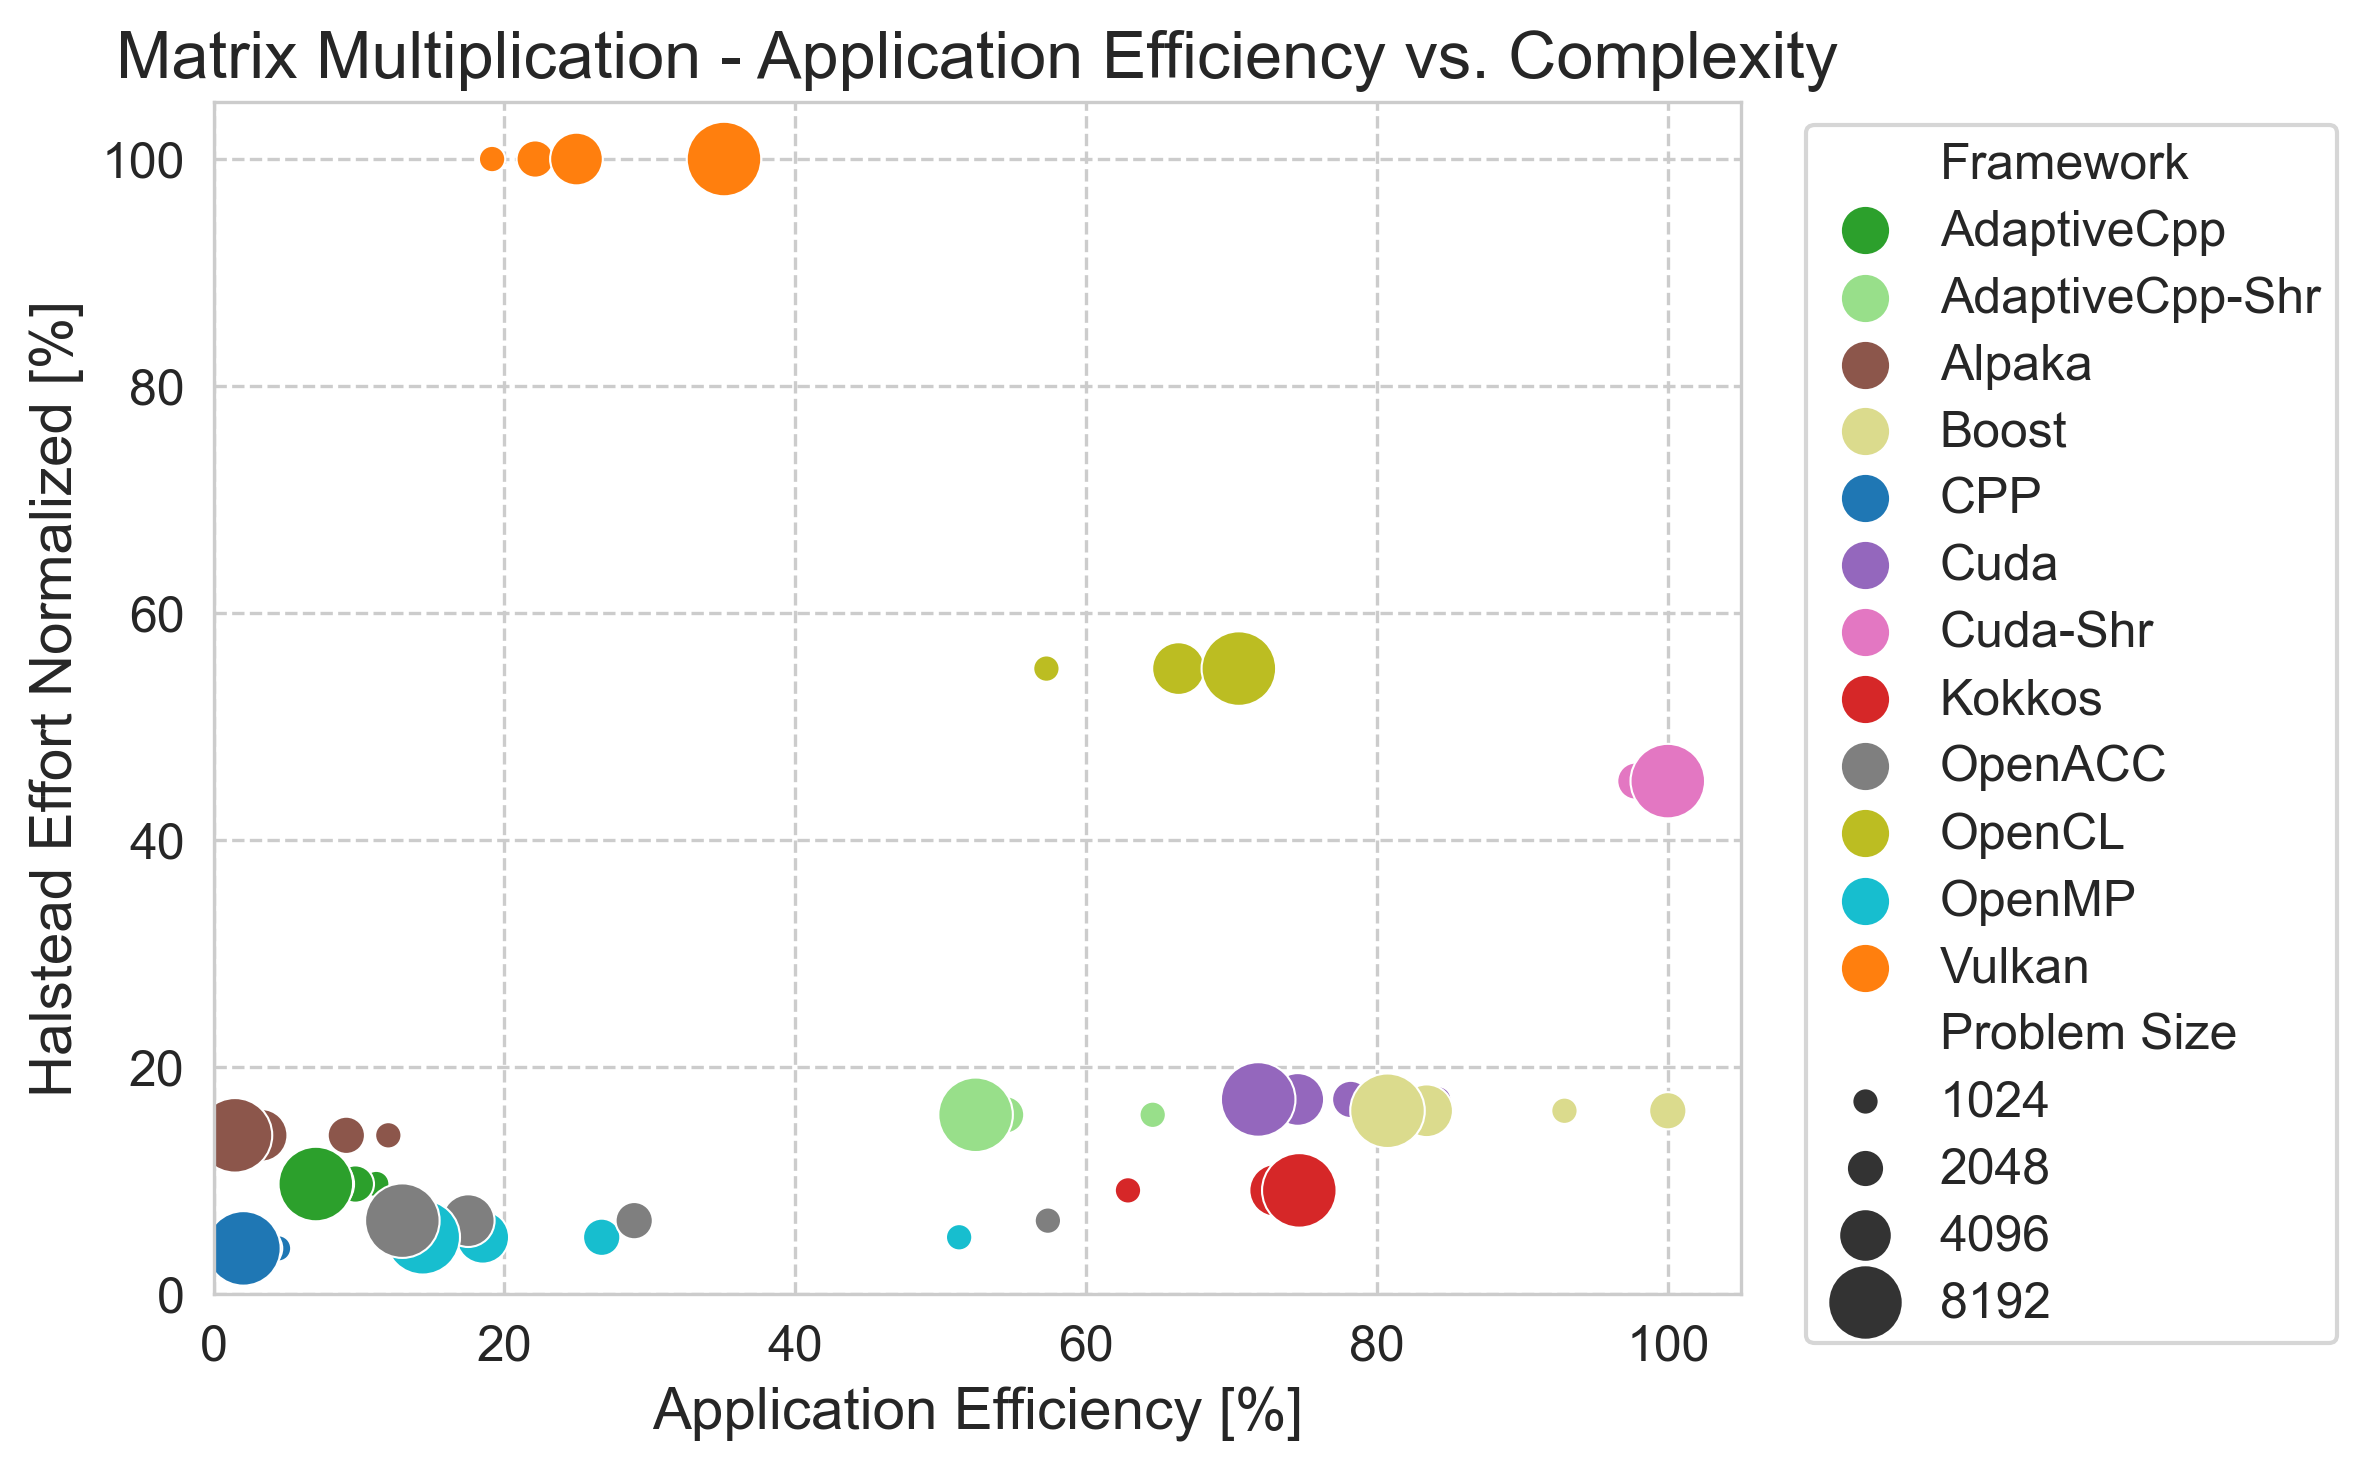

In [12]:
df_mm = filter_and_concat(df_merged, [
    ("MatrixMultiplication", 1024, "Wall Clock Time"),
    ("MatrixMultiplication", 2048, "Wall Clock Time"),
    ("MatrixMultiplication", 4096, "Wall Clock Time"),
    ("MatrixMultiplication", 8192, "Wall Clock Time")
])
plt.figure(figsize=(6, 5))
ax = sns.scatterplot(
    data=df_mm,
    x="Application Efficiency [%]",
    y="Halstead Effort Normalized [%]",
    hue="Framework",
    size="Problem Size",
    sizes=[40, 80, 160, 320],
    palette=color_map,
    s=140
)
ax.grid(True, linestyle="--")
ax.set_ylim(0, 105)
ax.set_xlim(0, 105)
ax.set_title("Matrix Multiplication - Application Efficiency vs. Complexity", fontsize=16)
ax.set_xlabel("Application Efficiency [%]", fontsize=14)
ax.set_ylabel("Halstead Effort Normalized [%]", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

# Move legend to the right outside the plot
legend = ax.legend_
if legend is not None:
    handles, labels = legend.legend_handles, [t.get_text() for t in legend.texts]
    legend.remove()
    if "Problem Size" in labels:
        split_idx = labels.index("Problem Size")
        fw_title = labels[0]
        fw_labels = labels[1:split_idx]
        size_title = labels[split_idx]
        size_labels = labels[split_idx + 1:]
        fw_handles = handles[1:split_idx]
        size_handles = handles[split_idx + 1:]
        # Sort framework legend alphabetically
        fw_pairs = sorted(zip(fw_labels, fw_handles), key=lambda x: x[0].lower())
        fw_labels_sorted, fw_handles_sorted = zip(*fw_pairs) if fw_pairs else ([], [])
        # Reassemble legend parts
        labels = [fw_title, *fw_labels_sorted, size_title, *size_labels]
        handles = [handles[0], *fw_handles_sorted, handles[split_idx], *size_handles]
    leg = ax.figure.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=True
    )
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(13)
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()


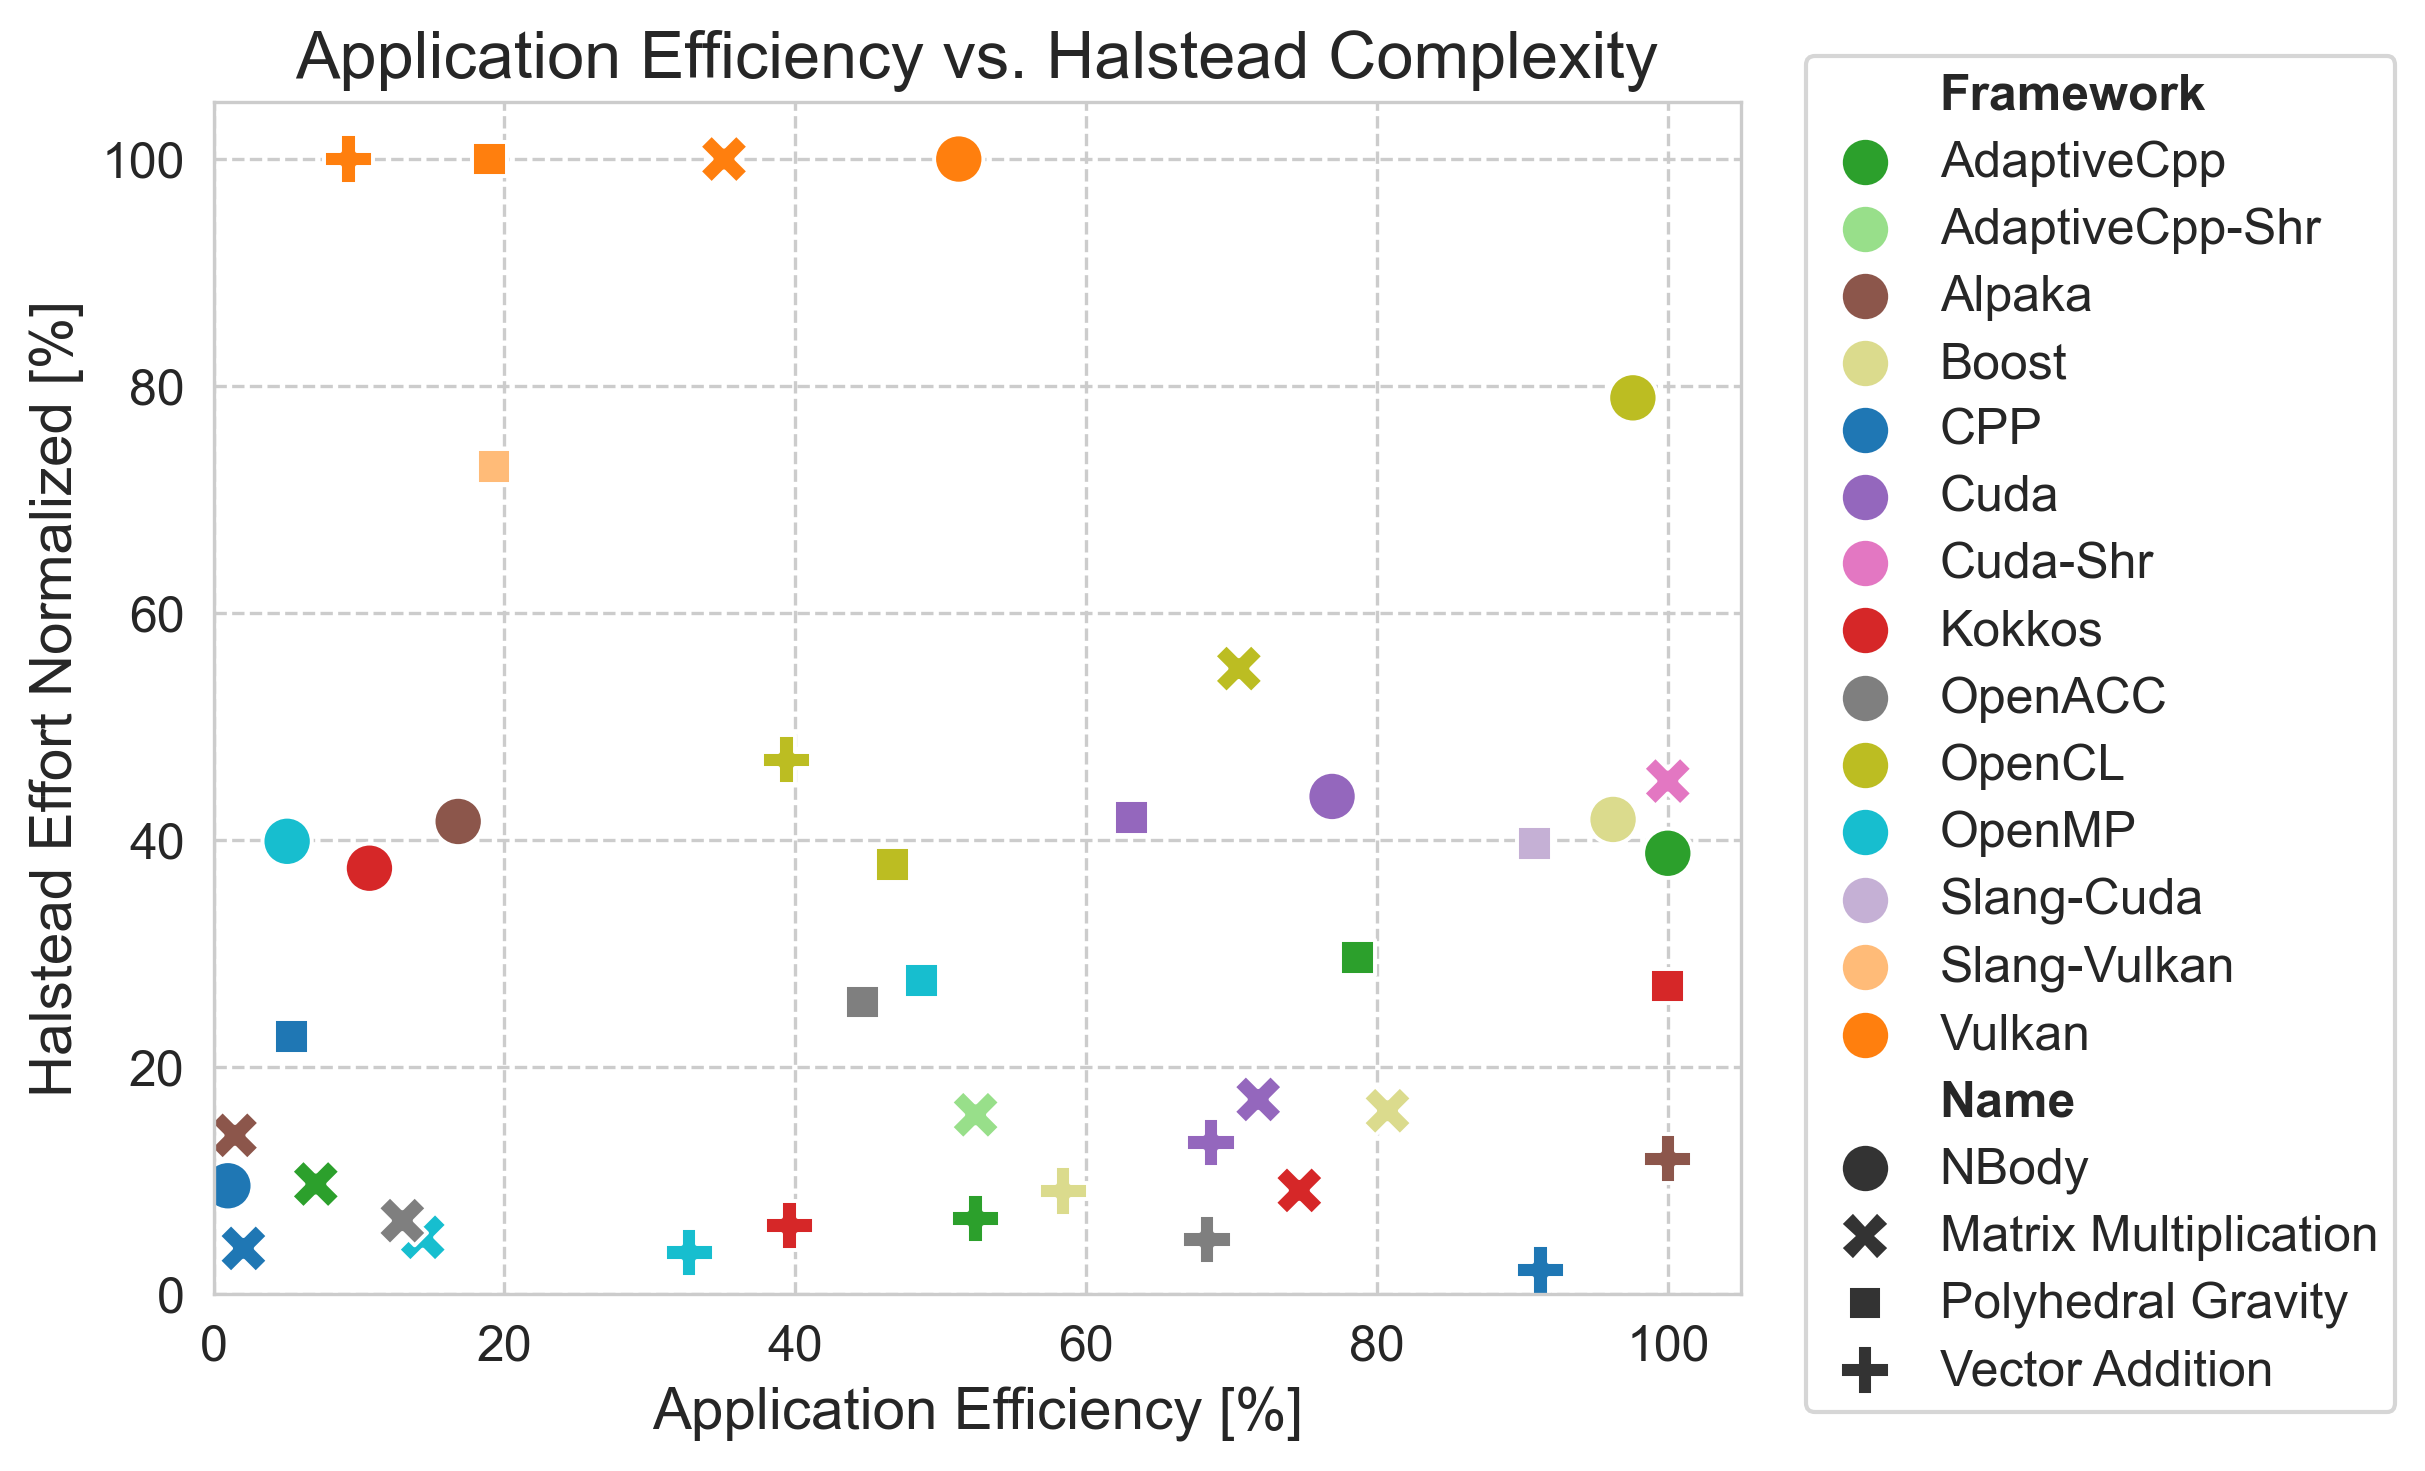

In [13]:
df_all = filter_and_concat(df_merged, [("PolyhedralGravity", 255932, "Wall Clock Time"),
                                       ("NBody", 10000, "Wall Clock Time"),
                                       ("MatrixMultiplication", 8192, "Wall Clock Time"),
                                       ("VecAdd", 10000000, "Wall Clock Time")
                                       ])
# Rename values in the 'Name' column so legend/style reflect new labels
df_all["Name"] = df_all["Name"].replace({
    "VecAdd": "Vector Addition",
    "PolyhedralGravity": "Polyhedral Gravity",
    "MatrixMultiplication": "Matrix Multiplication"
})

# Map specific marker styles per application
name_markers = {
    "Polyhedral Gravity": "s",  # square
    "Vector Addition": "+",  # plus
    "Matrix Multiplication": "x",  # x
    "NBody": "o"  # circle
}

plt.figure(figsize=(6, 5))
ax = sns.scatterplot(
    data=df_all,
    x="Application Efficiency [%]",
    y="Halstead Effort Normalized [%]",
    hue="Framework",
    style="Name",
    style_order=["NBody", "Matrix Multiplication", "Polyhedral Gravity", "Vector Addition"],
    palette=color_map,
    s=140
)
ax.grid(True, linestyle="--")
ax.set_ylim(0, 105)
ax.set_xlim(0, 105)
ax.set_title("Application Efficiency vs. Halstead Complexity", fontsize=16)
ax.set_xlabel("Application Efficiency [%]", fontsize=14)
ax.set_ylabel("Halstead Effort Normalized [%]", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

# Move legend to the right outside the plot
legend = ax.legend_
if legend is not None:
    handles, labels = legend.legend_handles, [t.get_text() for t in legend.texts]
    legend.remove()
    # Separate entries for Framework and Name
    if "Name" in labels:
        split_idx = labels.index("Name")
        fw_title = labels[0]
        fw_labels = labels[1:split_idx]
        size_title = labels[split_idx]
        size_labels = labels[split_idx + 1:]
        fw_handles = handles[1:split_idx]
        size_handles = handles[split_idx + 1:]
        # Sort framework legend alphabetically
        fw_pairs = sorted(zip(fw_labels, fw_handles), key=lambda x: x[0].lower())
        fw_labels_sorted, fw_handles_sorted = zip(*fw_pairs) if fw_pairs else ([], [])
        # Reassemble legend parts
        labels = [fw_title, *fw_labels_sorted, size_title, *size_labels]
        handles = [handles[0], *fw_handles_sorted, handles[split_idx], *size_handles]
    leg = ax.figure.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=True
    )
    if leg is not None:
        # Make section titles bold
        for txt in leg.get_texts():
            if txt.get_text() in ("Framework", "Name"):
                txt.set_fontweight("bold")
            txt.set_fontsize(12)
        if leg.get_title() is not None:
            leg.get_title().set_fontsize(13)
plt.tight_layout()
plt.gcf().set_dpi(300)
plt.show()


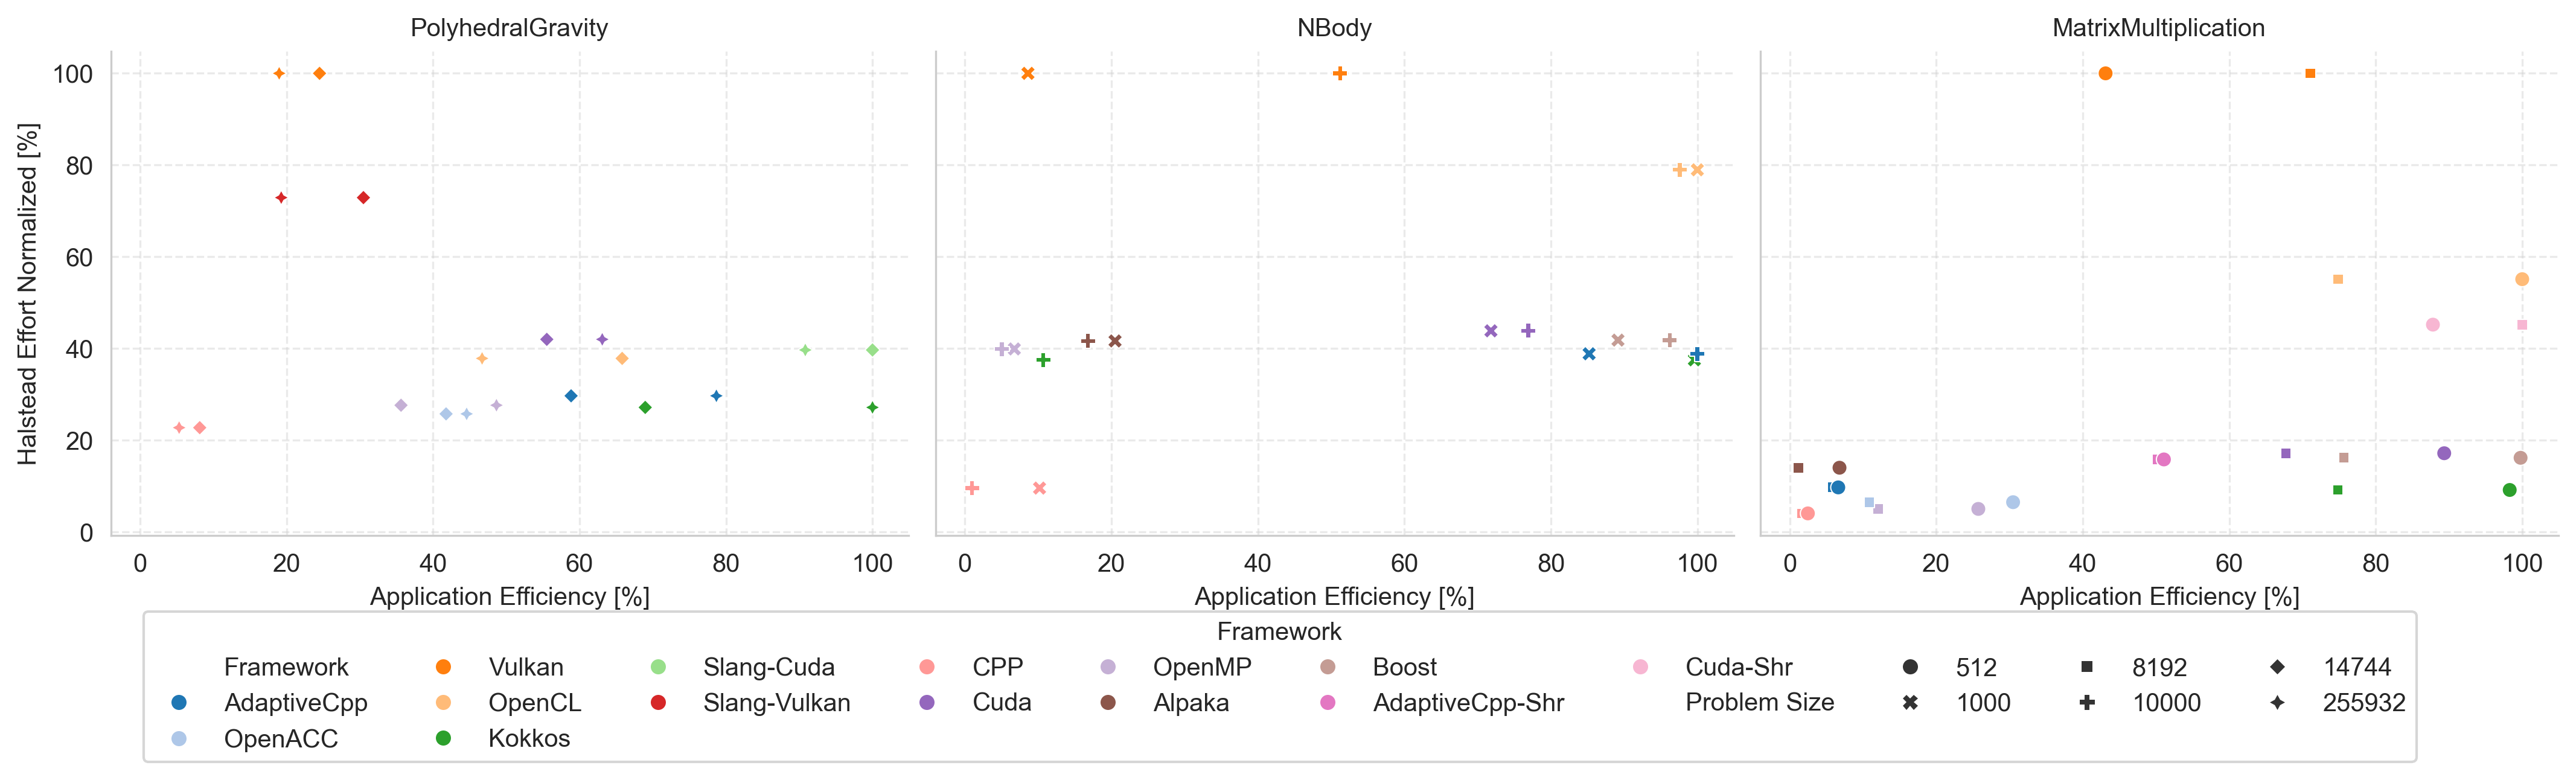

In [14]:
df_all = filter_and_concat(df_merged, [("PolyhedralGravity", 14744, "Wall Clock Time"),
                                     ("PolyhedralGravity", 255932, "Wall Clock Time"),
                                     ("NBody", 1000, "Wall Clock Time"),
                                     ("NBody", 10000, "Wall Clock Time"),
                                     ("MatrixMultiplication", 8192, "Kernel Time"),
                                     ("MatrixMultiplication", 512, "Kernel Time"),
                                     ], exclude="Cublas")

g = sns.relplot(
    data=df_all,
    x="Application Efficiency [%]",
    y="Halstead Effort Normalized [%]",
    hue="Framework",
    col="Name",
    style="Problem Size",
    palette="tab20",
    kind="scatter",
    height=4,
    aspect=1.2,
    legend="brief"
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Application Efficiency [%]", "Halstead Effort Normalized [%]")
for ax in g.axes.flat:
    ax.grid(True, linestyle="--", alpha=0.4)

# Place legend below plots, horizontal and centered and further down
leg = g._legend if hasattr(g, "_legend") and g._legend is not None else g.legend
if leg is not None:
    handles, labels = leg.legend_handles, [t.get_text() for t in leg.texts]
    leg.remove()
    g.fig.subplots_adjust(bottom=0.25)
    g.fig.legend(
        handles, labels,
        title="Framework",
        loc="lower center",
        bbox_to_anchor=(0.45, -0.08),
        ncol=10,
        frameon=True
    )
g.fig.set_dpi(300)
plt.show()
